In [1]:
import json
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow import keras
from TheModelFinalFinalV2 import build
from tqdm import tqdm
from tensorflow.keras.models import load_model

_, (x_test, y_test) = keras.datasets.mnist.load_data()
x_test = np.expand_dims(x_test, -1) / 255.0  

In [2]:
n= 5 #cantidad de integrantes
local_models = []
for i in range(n):
    local_model = load_model(f'local_model_{i}.keras')  
    local_models.append(local_model)

# FedAvg
local_weights = [model.get_weights() for model in local_models]
averaged_weights = [np.mean(np.array(weights), axis=0) for weights in zip(*local_weights)]
global_model = build.build_it()
global_model.set_weights(averaged_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Resultados del modelo global:")
print(classification_report(y_test, y_pred_classes))
global_model.save('global_model_FedAvg.keras')


313/313 [==============================] - 2s 5ms/step
Resultados del modelo global:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.93      0.95      0.94      1135
           2       0.78      0.68      0.73      1032
           3       0.98      0.32      0.48      1010
           4       1.00      0.01      0.02       982
           5       0.27      0.89      0.41       892
           6       0.95      0.06      0.11       958
           7       0.95      0.57      0.72      1028
           8       0.18      0.74      0.29       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.43     10000
   macro avg       0.60      0.42      0.37     10000
weighted avg       0.61      0.43      0.38     10000



c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [3]:
#Prueba de FedProx

local_weights = [model.get_weights() for model in local_models]
averaged_weights = [np.mean(np.array(weights), axis=0) for weights in zip(*local_weights)]

r = 0.1  
global_weights = averaged_weights.copy()
for i in range(len(averaged_weights)):
    global_weights[i] = averaged_weights[i] - r * (averaged_weights[i] - local_weights[0][i])


global_model.set_weights(global_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

global_model.save('global_model_Fedprox.keras')


313/313 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.93      0.96      0.94      1135
           2       0.78      0.86      0.82      1032
           3       0.91      0.69      0.79      1010
           4       0.00      0.00      0.00       982
           5       0.33      0.86      0.47       892
           6       0.97      0.03      0.06       958
           7       0.99      0.43      0.60      1028
           8       0.19      0.80      0.31       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.47     10000
   macro avg       0.51      0.46      0.40     10000
weighted avg       0.52      0.47      0.41     10000



c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [4]:
#Prueba de FedMax

local_weights = [model.get_weights() for model in local_models]

max_weights = []
for i in range(len(local_weights[0])):
    max_weight = np.max([local_weights[j][i] for j in range(len(local_weights))], axis=0)
    max_weights.append(max_weight)

global_model.set_weights(max_weights)

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

global_model.save('global_model_Fedmax.keras')


313/313 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.11      1.00      0.20      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.11     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.11      0.02     10000



c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\angel\anaconda3\envs\azureml38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 1/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.1448 - accuracy: 0.9571 - val_loss: 0.0485 - val_accuracy: 0.9834
Epoch 2/5
1875/1875 [==============================] - 33s 18ms/step - loss: 0.0469 - accuracy: 0.9855 - val_loss: 0.0368 - val_accuracy: 0.9877
Epoch 3/5
1875/1875 [==============================] - 35s 19ms/step - loss: 0.0317 - accuracy: 0.9901 - val_loss: 0.0399 - val_accuracy: 0.9877
Epoch 4/5
1875/1875 [==============================] - 34s 18ms/step - loss: 0.0256 - accuracy: 0.9923 - val_loss: 0.0301 - val_accuracy: 0.9898
Epoch 5/5
313/313 [==============================] - 2s 7ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0

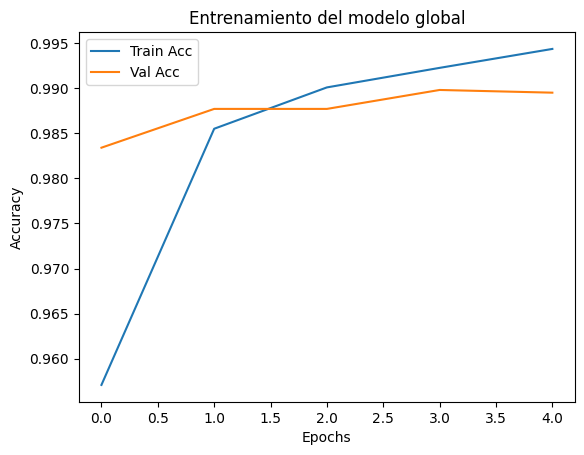

In [5]:
#Modelo general comparativa sin segmentacion (aprendizaje federado)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1).astype(np.float32) / 255.0
x_test = np.expand_dims(x_test, -1).astype(np.float32) / 255.0

model = build.build_it()

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Entrenamiento del modelo global')
plt.show()